In [ ]:
import torch
import torch.nn as nn
from torch.nn import functional as F

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from utils.train_utils.mmd import MMD
from torch_geometric.nn import GCNConv, SAGEConv, GATConv, GINConv


In [21]:
import utils.debug_utils as du
# importlib.reload( load_state )
import importlib

importlib.reload( du )

state = du.load_state()
globals().update(state)

In [ ]:

s_probs = F.softmax(source_logits, dim=1)
s_labels = source_data.y

t_probs = F.softmax(target_logits, dim=1)
t_labels = target_data.y

s_probs, t_probs, t_labels

s_logits = source_logits.detach().cpu().numpy()
t_logits = target_logits.detach().cpu().numpy()
s_probs = s_probs.detach().cpu().numpy()
t_probs = t_probs.detach().cpu().numpy()
s_labels = s_labels.detach().cpu().numpy()
t_labels = t_labels.detach().cpu().numpy()

In [46]:
source_logits

tensor([[-1.8628e-02, -3.9924e+00],
        [-5.3750e+00, -4.6416e-03],
        [-5.5391e+00, -3.9379e-03],
        ...,
        [-6.5507e+00, -1.4302e-03],
        [-5.2500e-02, -2.9731e+00],
        [-8.2794e-03, -4.7981e+00]], device='cuda:5', requires_grad=True)

In [ ]:
gnn = GCNConv(2, 2).to(source_logits.device)
# s_prop = gnn(source_logits, source_data.edge_index)
# source_logits.device, source_data.edge_index.device
# gnn.device, sou 
prop_logit_list = [source_logits]
num_layers = 3

for layer in range(num_layers):
    prop_logit = gnn( prop_logit_list[-1], source_data.edge_index)



<Axes: >

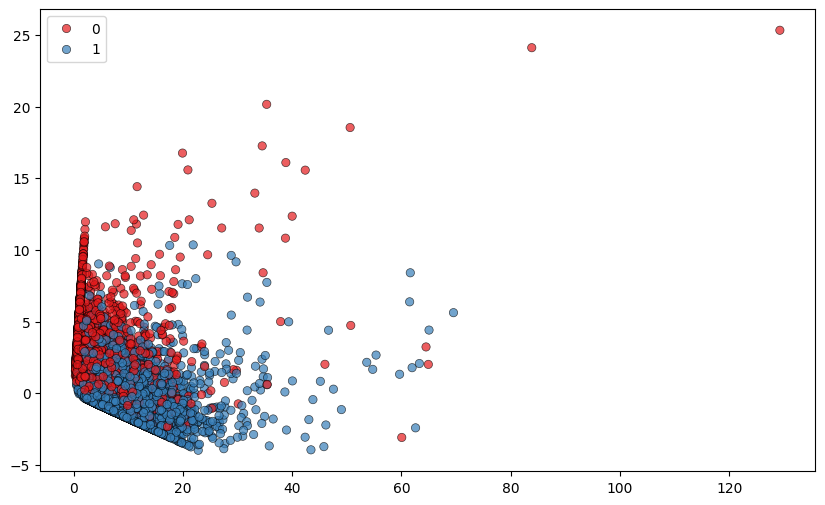

In [54]:
s_prop = s_prop.detach().cpu().numpy()

plt.figure(figsize=(10, 6))
sns.scatterplot(x=s_prop[:, 0], y=s_prop[:, 1], hue=s_labels, palette='Set1', alpha=0.7, edgecolor='k')

<Axes: >

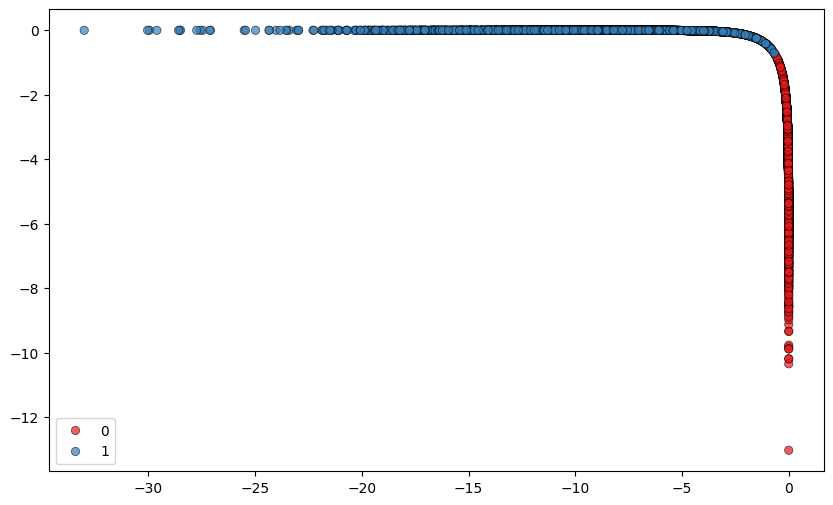

In [39]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=s_logits[:, 0], y=s_logits[:, 1], hue=s_labels, palette='Set1', alpha=0.7, edgecolor='k')

<Axes: >

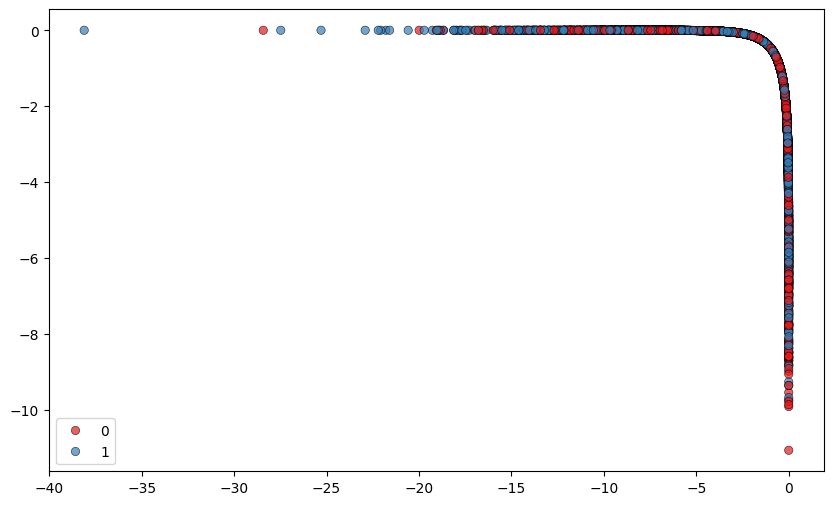

In [40]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=t_logits[:, 0], y=t_logits[:, 1], hue=t_labels, palette='Set1', alpha=0.7, edgecolor='k')

<Axes: >

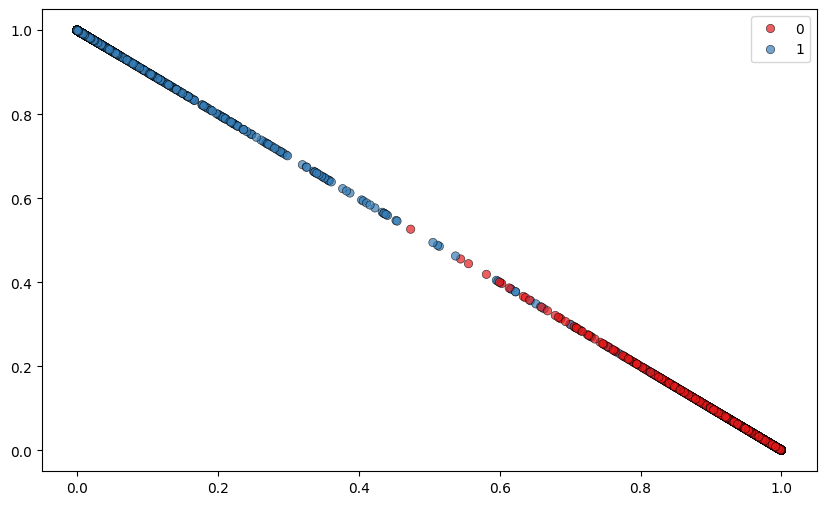

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=s_probs[:, 0], y=s_probs[:, 1], hue=s_labels, palette='Set1', alpha=0.7, edgecolor='k')

<Axes: >

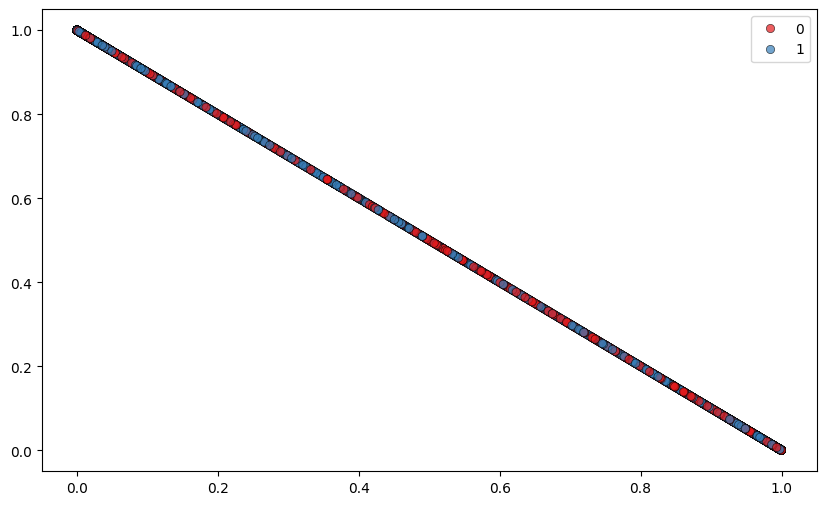

In [37]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=t_probs[:, 0], y=t_probs[:, 1], hue=t_labels, palette='Set1', alpha=0.7, edgecolor='k')

<Axes: >

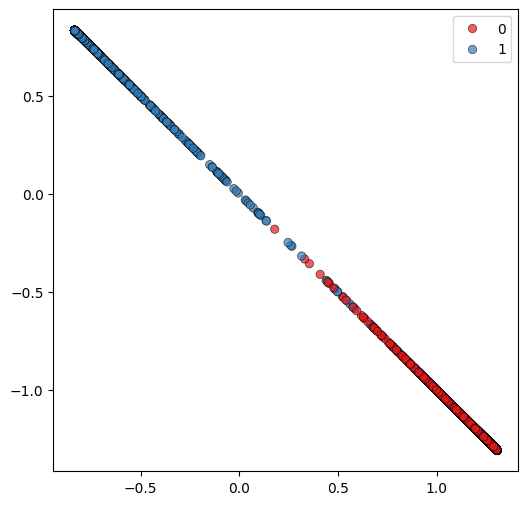

In [ ]:
# 
s_prob_mean = s_probs.mean(axis=0)
t_prob_mean = t_probs.mean(axis=0)
s_prob_std = s_probs.std(axis=0)
t_prob_std = t_probs.std(axis=0)
s_logit_mean = s_logits.mean(axis=0)
t_logit_mean = t_logits.mean(axis=0)
s_logit_std = s_logits.std(axis=0)
t_logit_std = t_logits.std(axis=0)


s_prob_norm = (s_probs - s_prob_mean) / s_prob_std
t_prob_norm = (t_probs - t_prob_mean) / t_prob_std
s_logit_norm = (s_logits - s_logit_mean) / s_logit_std
t_logit_norm = (t_logits - t_logit_mean) / t_logit_std

gnn =GCNConv(2, 2)
s_prop = gnn( torch.tensor(s_logit_norm, dtype=torch.float32), source_data.edge_index)

# s_logit_mean2 = s_logit_norm.mean(axis=1)
# t_logit_mean2 = t_logit_norm.mean(axis=1)
# s_logit_std2 = s_logit_norm.std(axis=1)
# t_logit_std2 = t_logit_norm.std(axis=1)
# s_logit_norm2 = (s_logit_norm - s_logit_mean2[:, None])/s_logit_std2[:, None]
# t_logit_norm2 = (t_logit_norm - t_logit_mean2[:, None])/t_logit_std2[:, None]

plt.figure(figsize=(6, 6))
sns.scatterplot(x=t_prob_norm[:, 0], y=t_prob_norm[:, 1], hue=s_labels, palette='Set1', alpha=0.7, edgecolor='k')
# sns.scatterplot(x=s_logit_norm2[:, 0], y=s_logit_norm2[:, 1], hue=s_labels, palette='Set1', alpha=0.7, edgecolor='k')

In [36]:
s_prob_norm

array([[ 1.2666249 , -1.2666309 ],
       [-0.82492816,  0.82492226],
       [-0.8264282 ,  0.82642233],
       ...,
       [-0.831783  ,  0.831777  ],
       [ 1.1966361 , -1.196642  ],
       [ 1.2884856 , -1.2884917 ]], dtype=float32)